Epoch 1, Loss: 154.1681
Epoch 2, Loss: 118.5325
Epoch 3, Loss: 113.9294
Epoch 4, Loss: 111.5463
Epoch 5, Loss: 110.1148
Epoch 6, Loss: 109.0082
Epoch 7, Loss: 108.3071
Epoch 8, Loss: 107.6590
Epoch 9, Loss: 107.2211
Epoch 10, Loss: 106.7813


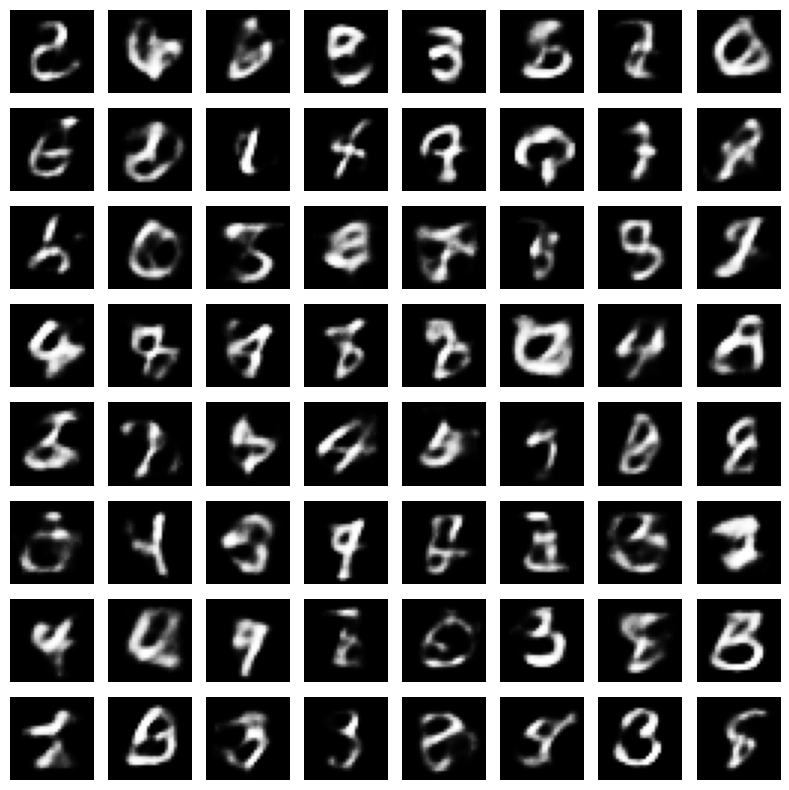

In [12]:
import jax
import jax.numpy as jnp
from jax import random

from flax import linen as nn
from flax.training import train_state

import optax
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_datasets as tfds

# -----------------------
# Model definition
# -----------------------

class Encoder(nn.Module):
    latent_dim: int

    @nn.compact
    def __call__(self, x):
        # x: (batch, 28, 28, 1)
        x = x.reshape((x.shape[0], -1))  # flatten
        x = nn.Dense(400)(x)
        x = nn.relu(x)
        x = nn.Dense(self.latent_dim * 2)(x)  # [mu, logvar]
        mu, logvar = jnp.split(x, 2, axis=-1)
        return mu, logvar


class Decoder(nn.Module):
    latent_dim: int

    @nn.compact
    def __call__(self, z):
        z = nn.Dense(400)(z)
        z = nn.relu(z)
        z = nn.Dense(28 * 28)(z)
        z = nn.sigmoid(z)
        z = z.reshape((z.shape[0], 28, 28, 1))
        return z


class VAE(nn.Module):
    latent_dim: int

    def setup(self):
        self.encoder = Encoder(self.latent_dim)
        self.decoder = Decoder(self.latent_dim)

    def __call__(self, x, rng):
        mu, logvar = self.encoder(x)
        std = jnp.exp(0.5 * logvar)
        eps = random.normal(rng, std.shape)
        z = mu + std * eps
        x_recon = self.decoder(z)
        return x_recon, mu, logvar

    def decode(self, z):
        return self.decoder(z)


# -----------------------
# Loss and train state
# -----------------------

def binary_cross_entropy(recon_x, x):
    # both in [0,1], shape (batch, 28, 28, 1)
    eps = 1e-7
    recon_x = jnp.clip(recon_x, eps, 1.0 - eps)
    bce = -(x * jnp.log(recon_x) + (1.0 - x) * jnp.log(1.0 - recon_x))
    return jnp.sum(bce)  # sum over all pixels and batch


def kl_divergence(mu, logvar):
    # KL(q(z|x) || p(z)) for diagonal Gaussians
    return -0.5 * jnp.sum(1.0 + logvar - jnp.square(mu) - jnp.exp(logvar))


def create_train_state(rng, latent_dim, learning_rate):
    vae = VAE(latent_dim=latent_dim)
    dummy_x = jnp.zeros((1, 28, 28, 1), jnp.float32)
    params = vae.init(rng, dummy_x, rng)["params"]
    tx = optax.adam(learning_rate)
    return train_state.TrainState.create(apply_fn=vae.apply, params=params, tx=tx), vae


# -----------------------
# Data pipeline
# -----------------------

def preprocess(example):
    image = example["image"]  # uint8 [0,255]
    image = jnp.array(image, dtype=jnp.float32) / 255.0
    image = image[..., None] if image.ndim == 3 else image  # ensure channel dim
    return image


def get_dataloader(batch_size):
    # Load MNIST as a tf.data.Dataset
    ds = tfds.load("mnist", split="train", shuffle_files=True)

    def _preprocess(example):
        # example["image"]: uint8 [28, 28, 1] or [28, 28]
        img = tf.cast(example["image"], tf.float32) / 255.0
        # ensure shape (28, 28, 1)
        if img.shape.rank == 2:
            img = tf.expand_dims(img, -1)
        return img

    ds = ds.map(_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.shuffle(1024)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    # Now convert the whole dataset to a Python iterable of NumPy arrays
    return tfds.as_numpy(ds)


# -----------------------
# Training step
# -----------------------

@jax.jit
def train_step(state, batch, rng, batch_size):
    def loss_fn(params):
        x = batch
        x_recon, mu, logvar = state.apply_fn({"params": params}, x, rng)
        bce = binary_cross_entropy(x_recon, x)
        kld = kl_divergence(mu, logvar)
        loss = (bce + kld) / batch_size
        return loss

    loss, grads = jax.value_and_grad(loss_fn)(state.params)
    state = state.apply_gradients(grads=grads)
    return state, loss


# -----------------------
# Sample generation
# -----------------------

def generate_samples(state, vae, latent_dim, num_samples, rng):
    z_rng, apply_rng = random.split(rng)
    z = random.normal(z_rng, (num_samples, latent_dim))
    x_recon = vae.apply({"params": state.params}, z, method=VAE.decode)
    x_recon = np.array(x_recon)  # to numpy for plotting
    return x_recon


def plot_samples(samples, nrow=8, ncol=8):
    fig, axes = plt.subplots(nrow, ncol, figsize=(ncol, nrow))
    idx = 0
    for i in range(nrow):
        for j in range(ncol):
            axes[i, j].imshow(samples[idx, :, :, 0], cmap="gray")
            axes[i, j].axis("off")
            idx += 1
    plt.tight_layout()
    plt.show()


# -----------------------
# Main
# -----------------------

def main():
    batch_size = 128
    latent_dim = 20
    learning_rate = 1e-3
    num_epochs = 10

    rng = random.PRNGKey(0)
    rng, init_rng = random.split(rng)

    state, vae = create_train_state(init_rng, latent_dim, learning_rate)
    dataloader = get_dataloader(batch_size)

    for epoch in range(1, num_epochs + 1):
        epoch_loss = 0.0
        num_batches = 0
        for batch in dataloader:
            rng, step_rng = random.split(rng)
            state, loss = train_step(state, batch, step_rng, batch_size)
            epoch_loss += float(loss)
            num_batches += 1

        avg_loss = epoch_loss / max(1, num_batches)
        print(f"Epoch {epoch}, Loss: {avg_loss:.4f}")

    # Generate samples after training
    rng, sample_rng = random.split(rng)
    samples = generate_samples(state, vae, latent_dim, num_samples=64, rng=sample_rng)
    plot_samples(samples)


if __name__ == "__main__":
    main()

In [7]:
pip install tensorflow_datasets

Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for tensorflow_datasets from https://files.pythonhosted.org/packages/16/e0/657192dbc03636532ccbd5c90669d31a65187365b99ba685db36bb31dd67/tensorflow_datasets-4.9.9-py3-none-any.whl.metadata
  Obtaining dependency information for array_record>=0.5.0 from https://files.pythonhosted.org/packages/1c/71/73a18fc9e40433a47f535d34dfb9056a45e5577856daa1d7f0a7d54a93da/array_record-0.8.3-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata
  Obtaining dependency information for immutabledict from https://files.pythonhosted.org/packages/63/7b/04ab6afa1ff7eb9ccb09049918c0407b205f5009092c0416147d163e4e2b/immutabledict-4.2.2-py3-none-any.whl.metadata
  Preparing metadata (setup.py) ... done
  Obtaining dependency information for simple_parsing from https://files.pythonhosted.org/packages/4f/9c/e9ea38750027a6de3e3c5e68a19fda0e7b0cd3db8045f30d0f6bc113b911/simple_parsing-0.1.7-py

Saved generated samples to mnist_vae_samples.png


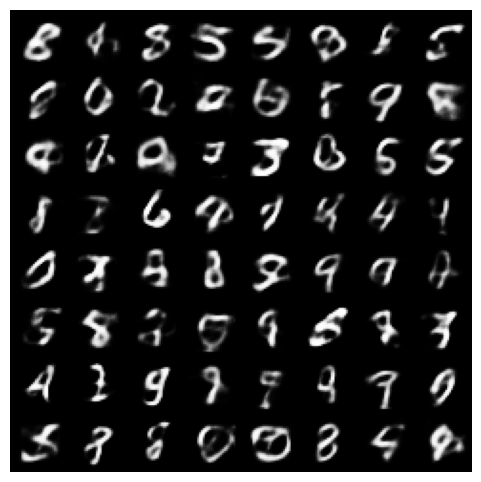

In [5]:
# 2) use the trained VAE to generate new MNIST-like digits
generate_samples(vae, num_samples=64, latent_dim=20, out_path="mnist_vae_samples.png")